# Surface wear from height matrices

CPU reference notebook: load TrueMapData surfaces, run the height-matrix wear loop from `tmd.sequence`, inspect contact and cumulative wear, then export logs and a mesh.

**Pipeline:** `load_surfaces_for_simulation` → `select_pair` → `compute_contact` → `run_simulation` → metrics / GIF / `.mat` + `.npz` exports. Surfaces **master** (`MS`) and **slave** (`SS`) use hardness for both slip-energy partition (∝ 1/H) and wear-depth scaling (1/H).

**Reference:** Sun, D. (2025). *Surface wear characterized by height matrix…* Mendeley Data. https://doi.org/10.17632/v635kysfr2.1


In [1]:
from __future__ import annotations

import json
from dataclasses import asdict
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from IPython.display import Image, display

from tmd.model.base import export_heightmap_to_model
from tmd.sequence import (
    DIRECTION_NAMES,
    WearParameters,
    combined_mu,
    compare_surface_pairs,
    compute_contact,
    export_final_state_mat,
    load_surfaces_for_simulation,
    ms_snapshots_to_sequence,
    pixel_pitch_mm_from_metadata,
    run_simulation,
    select_pair,
    simulation_metadata_to_pitch,
    truemap_repo_root,
)
from tmd.surface.metrics import preferred_slip_axis, surface_metrics_summary, texture_direction_spectrum
from tmd.surface.metrics.curvature import (
    normal_orientation_summary,
    pixel_spacing_dy_dx_from_metadata,
)


def configure_matplotlib_notebook() -> None:
    plt.rcParams.update(
        {
            "figure.dpi": 110,
            "figure.figsize": (7, 5),
            "axes.grid": True,
            "grid.alpha": 0.25,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "image.cmap": "viridis",
        }
    )


configure_matplotlib_notebook()
np.set_printoptions(precision=5, suppress=True)


def synthetic_sandpaper_120_grit(
    shape: tuple[int, int],
    *,
    rng: np.random.Generator | None = None,
    grit_nominal: int = 120,
) -> np.ndarray:
    """Coarse abrasive-sheet height (demo): random grain plateaus with pitch ~ 1/sqrt(grit).

    Intended as a stand-in for ~120 grit fixed abrasive: spacing scales with ``grit_nominal``
    on the pixel grid (not ISO-calibrated). Voronoi cells get independent random heights plus
    a little white noise for micro-roughness.
    """
    rng = np.random.default_rng(0) if rng is None else rng
    h, w = int(shape[0]), int(shape[1])
    g = max(40.0, float(grit_nominal))
    pitch = max(5, int(round(min(h, w) * 0.55 / np.sqrt(g))))
    ys = np.arange(pitch // 2, h + pitch, pitch, dtype=np.float64)
    xs = np.arange(pitch // 2, w + pitch, pitch, dtype=np.float64)
    yy0, xx0 = np.meshgrid(ys, xs, indexing="ij")
    cy = np.clip(yy0 + rng.uniform(-0.28, 0.28, size=yy0.shape) * pitch, 0.0, h - 1.0).ravel()
    cx = np.clip(xx0 + rng.uniform(-0.28, 0.28, size=xx0.shape) * pitch, 0.0, w - 1.0).ravel()
    K = int(cy.size)
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float64)
    best_d = np.full((h, w), np.inf, dtype=np.float64)
    best_k = np.zeros((h, w), dtype=np.int32)
    block = 72
    for t in range(0, K, block):
        te = min(K, t + block)
        cyb = cy[t:te]
        cxb = cx[t:te]
        d2 = (yy[..., None] - cyb[None, None, :]) ** 2 + (xx[..., None] - cxb[None, None, :]) ** 2
        dm = np.sqrt(np.maximum(d2, 0.0)).min(axis=2)
        lm = np.argmin(d2, axis=2) + np.int32(t)
        pick = dm < best_d
        best_d = np.where(pick, dm, best_d)
        best_k = np.where(pick, lm, best_k)
    amps = rng.standard_normal(K).astype(np.float64)
    z = amps[best_k] + 0.12 * rng.standard_normal((h, w))
    z = z - float(np.mean(z))
    s = float(np.std(z))
    if s > 1e-12:
        z /= s
    return z.astype(np.float64, copy=False)


# --- Session constants -------------------------------------------------------
MS_IDX: int = 1
SS_IDX: int = 2
SLIDE_DIR: int = 1
LOAD_CONTROLLED: bool = False
N_STEPS: int = 200
SAVE_EVERY: int = 20

HARDNESS_MASTER: float = 1.0
HARDNESS_SLAVE: float = 3.0
# Slip energy is partitioned master/slave ∝ 1/H each step; wear depth still scales as (energy/H) per body.

PLOT_PAIR_3D_H0: float = -2.0
PLOT_PAIR_3D_STRIDE: int = 8

INPUT_A: "str | Path | None" = None
INPUT_B: "str | Path | None" = None
SECOND_SURFACE_MODE: str = "flat"
MAX_GRID_DIM: int = 256
NORMALIZE_TO_UNIT_SQ: bool = True

# When True and ``INPUT_B`` is None, replace the flat slave (higher ``HARDNESS_SLAVE`` counterface)
# with a synthetic ~120-grit abrasive height field matched to the master grid shape.
SANDPAPER_120_GRIT_SLAVE: bool = True

REPO_ROOT = truemap_repo_root()
NOTEBOOK_EXPORT_ROOT = REPO_ROOT / "notebooks"
WEAR_RESULTS_DIR = NOTEBOOK_EXPORT_ROOT / "wear_results"

published_params = WearParameters()
demo_params = WearParameters(
    h0=-2.0,
    wear_scale=1.0,
    wear_clamp_frac=0.03,
    wear_mode="topk",
    max_wear_fraction=0.02,
    hardness_master=HARDNESS_MASTER,
    hardness_slave=HARDNESS_SLAVE,
)

pd.DataFrame({"published_params": asdict(published_params), "demo_params": asdict(demo_params)})


,published_params,demo_params
h0,1.3,-2.0
E,0.103,0.103
poisson,0.34,0.34
f0,0.075,0.075
G,0.041,0.041
R,0.5,0.5
deltaw,0.0,0.0
normalF,0.00359,0.00359
normal_error,0.0001,0.0001
delta_slid,1.0,1.0


## Load surfaces

`INPUT_A` / `INPUT_B`: `.tmd` or `.mat`, or `None` to auto-discover. `SECOND_SURFACE_MODE` applies when `INPUT_B` is `None`. Use `select_pair` for the master–slave grids (sign convention is handled in the library).

With **`SANDPAPER_120_GRIT_SLAVE = True`** and no `INPUT_B`, the **slave** grid (higher `HARDNESS_SLAVE` in the default demo) is replaced by a synthetic **~120-grit** abrasive texture matched to the master shape (not ISO-calibrated; for visualization and contact experiments only).


In [2]:
surfaces, stored_surface_params, truemap_metadata, _resolved_mode = load_surfaces_for_simulation(
    INPUT_A,
    INPUT_B,
    second_surface_mode=SECOND_SURFACE_MODE,
    max_grid_dim=MAX_GRID_DIM,
    normalize_to_unit_sq=NORMALIZE_TO_UNIT_SQ,
    repo_root=REPO_ROOT,
)

if SANDPAPER_120_GRIT_SLAVE and INPUT_B is None and SS_IDX in surfaces:
    shp = surfaces[MS_IDX].shape
    surfaces[SS_IDX] = synthetic_sandpaper_120_grit(
        (int(shp[0]), int(shp[1])), rng=np.random.default_rng(11), grit_nominal=120
    )
    stored_surface_params[SS_IDX] = {"source": "synthetic_120_grit_sandpaper", "grit_nominal": 120}
    truemap_metadata["slave"] = "synthetic_120_grit_sandpaper"

input_path = Path(truemap_metadata["input_a"])
print(f"Loaded {len(surfaces)} surfaces, mode={_resolved_mode}")
print(f"  master: {input_path} ({truemap_metadata['input_a_kind']})")
if truemap_metadata.get("input_b") is not None:
    print(f"  slave:  {truemap_metadata['input_b']} ({truemap_metadata.get('input_b_kind')})")
else:
    print(f"  slave:  {truemap_metadata.get('slave', 'n/a')}")
print("Shape:", next(iter(surfaces.values())).shape)

if truemap_metadata:
    display(pd.Series(truemap_metadata, name="value").to_frame())
pd.DataFrame(stored_surface_params).T.round(5)


Loaded 2 surfaces, mode=flat
  master: E:\TrueMapData\examples\gelsight\circle_0mm_100g_heightmap_linear_detrend.tmd (tmd)
  slave:  synthetic_120_grit_sandpaper
Shape: (171, 256)


,value
input_a,E:\TrueMapData\examples\gelsight\circle_0mm_10...
input_a_kind,tmd
second_surface_mode,flat
a_mmpp,0.001274
a_x_length,7.675058
a_y_length,5.12435
a_x_offset,0.0
a_y_offset,0.0
a_width,6024.0
a_height,4022.0


,source,path,grit_nominal
1,tmd,E:\TrueMapData\examples\gelsight\circle_0mm_10...,NaN
2,synthetic_120_grit_sandpaper,NaN,120


## Plotting helpers and gallery

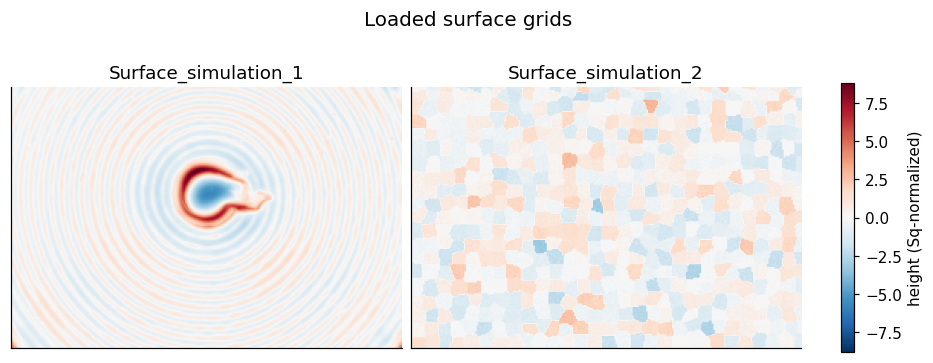

In [3]:
def imshow_field(ax, Z, title: str, cmap: str = "viridis", vmin=None, vmax=None, cbar: bool = True):
    im = ax.imshow(Z, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    if cbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


def robust_limits(arrays, q=(1, 99)):
    x = np.concatenate([np.asarray(a).ravel() for a in arrays])
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 0.0, 1.0
    lo, hi = np.percentile(x, q)
    if np.isclose(lo, hi):
        hi = lo + 1e-12
    return float(lo), float(hi)


def plot_surface_gallery(surfaces: Dict[int, np.ndarray]) -> None:
    n = len(surfaces)
    if not n:
        return
    ncol = min(3, n)
    nrow = int(np.ceil(n / ncol))
    vmax = max(float(np.max(np.abs(Z))) for Z in surfaces.values())
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.6 * nrow), constrained_layout=True)
    axes_flat = np.atleast_1d(axes).ravel()
    im = None
    for ax, (idx, Z) in zip(axes_flat, surfaces.items()):
        im = imshow_field(ax, Z, f"Surface_simulation_{idx}", cmap="RdBu_r", vmin=-vmax, vmax=vmax, cbar=False)
    for ax in axes_flat[len(surfaces) :]:
        ax.axis("off")
    if im is not None:
        fig.colorbar(im, ax=axes_flat.tolist(), shrink=0.75, label="height (Sq-normalized)")
    fig.suptitle("Loaded surface grids", fontsize=13)
    plt.show()


def plot_pair_3d(MS: np.ndarray, SS: np.ndarray, h0_demo: float | None = None, stride: int | None = None) -> None:
    if h0_demo is None:
        h0_demo = PLOT_PAIR_3D_H0
    if stride is None:
        stride = PLOT_PAIR_3D_STRIDE
    fig = plt.figure(figsize=(13, 5.5))
    sub = MS[::stride, ::stride]
    yy, xx = np.meshgrid(np.arange(sub.shape[0]), np.arange(sub.shape[1]), indexing="ij")

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(xx, yy, sub, cmap="viridis", linewidth=0, antialiased=True)
    ax1.set_title(f"MS (Surface_{MS_IDX})")
    ax1.set_xlabel("u")
    ax1.set_ylabel("v")
    ax1.set_zlabel("height")

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.plot_surface(xx, yy, MS[::stride, ::stride], cmap="Blues", linewidth=0, antialiased=True, alpha=0.85)
    ax2.plot_surface(xx, yy, SS[::stride, ::stride] - h0_demo, cmap="Reds", linewidth=0, antialiased=True, alpha=0.55)
    ax2.set_title(f"MS (blue) and SS−h0 (red), h0 = {h0_demo}")
    ax2.set_xlabel("u")
    ax2.set_ylabel("v")
    ax2.set_zlabel("height")
    plt.tight_layout()
    plt.show()


def plot_contact_dashboard(c: dict, title: str = "Contact dashboard") -> None:
    fields = [
        (np.where(c["mask"], c["d"], np.nan), "penetration d", "viridis"),
        (c["mask"].astype(float), "contact mask", "Greys"),
        (np.where(c["mask"], c["deltaF"], np.nan), "normal force dF", "magma"),
        (np.where(c["mask"], c["tau"], np.nan), "traction tau", "inferno"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
    for ax, (Z, label, cmap) in zip(axes, fields):
        imshow_field(ax, Z, label, cmap=cmap)
    fig.suptitle(title, fontsize=13)
    plt.show()


def plot_diagnostics(log: pd.DataFrame, p: WearParameters) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, constrained_layout=True)
    axes[0, 0].plot(log.index, log["contact_texels"])
    axes[0, 0].set_title("Contact texels")
    axes[0, 0].set_ylabel("count")
    axes[0, 1].plot(log.index, log["normal_force"])
    axes[0, 1].set_title("Total normal force")
    axes[0, 1].set_ylabel("force")
    axes[1, 0].plot(log.index, log["wear_volume_MS"].cumsum(), label="MS wear / step (cum)")
    axes[1, 0].plot(log.index, log["wear_volume_SS"].cumsum(), label="SS wear / step (cum)")
    axes[1, 0].plot(log.index, log["cumulative_wear_sum_MS"], "--", label="cum wear vol MS")
    axes[1, 0].plot(log.index, log["cumulative_wear_sum_SS"], "--", label="cum wear vol SS")
    axes[1, 0].set_title("Wear volumes")
    axes[1, 0].set_xlabel("step")
    axes[1, 0].legend(fontsize=8)
    axes[1, 1].plot(log.index, log["energy_max_MS"], label="max energy MS")
    axes[1, 1].axhline(p.deltaw, color="0.4", ls="--", lw=1, label="wear threshold")
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_title("Wear energy headroom")
    axes[1, 1].set_xlabel("step")
    axes[1, 1].legend()
    fig.suptitle("Simulation diagnostics")
    plt.show()


def plot_evolution_grid(snapshots: Dict[int, dict]) -> None:
    steps = sorted(snapshots)
    fields = [
        ("MS", "MS height", "viridis"),
        ("SS", "SS height", "cividis"),
        ("mask", "contact mask", "Greys"),
        ("tau", "traction tau", "inferno"),
        ("wear_map", "cum. wear MS", "hot"),
        ("wear_map_SS", "cum. wear SS (body)", "hot"),
        ("sliding_distance_slave", "cum. slip (slave body)", "plasma"),
    ]
    limits: Dict[str, Tuple[float, float]] = {}
    for key, _, _ in fields:
        values = [snapshots[s][key] for s in steps]
        if key == "mask":
            limits[key] = (0.0, 1.0)
        elif key in {"tau", "wear_map", "wear_map_SS", "sliding_distance_slave"}:
            positive = [v[v > 0] for v in values if np.any(v > 0)]
            limits[key] = robust_limits(positive, q=(1, 99.5)) if positive else (0.0, 1.0)
        else:
            limits[key] = robust_limits(values, q=(1, 99))
    fig, axes = plt.subplots(
        len(steps), len(fields), figsize=(2.4 * len(fields), 2.5 * len(steps)), constrained_layout=True
    )
    if len(steps) == 1:
        axes = axes[None, :]
    for r, step_idx in enumerate(steps):
        for c, (key, label, cmap) in enumerate(fields):
            ax = axes[r, c]
            vmin, vmax = limits[key]
            im = ax.imshow(snapshots[step_idx][key], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            if r == 0:
                ax.set_title(label, fontsize=9)
            if c == 0:
                ax.set_ylabel(f"step {step_idx}")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(False)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    fig.suptitle("Wear evolution over time")
    plt.show()


def plot_contact_cross_section(MS: np.ndarray, SS: np.ndarray, contact: dict) -> None:
    row = int(np.unravel_index(np.argmax(contact["tau"]), contact["tau"].shape)[0])
    x = np.arange(MS.shape[1])
    upper = MS[row]
    lower = SS[row] - contact["h0"]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)
    axes[0].plot(x, upper, label="MS")
    axes[0].plot(x, lower, label="SS - h0")
    axes[0].fill_between(x, upper, lower, where=upper > lower, alpha=0.35, label="penetration")
    axes[0].set_title(f"Height cross-section (max-traction row {row})")
    axes[0].set_ylabel("height")
    axes[0].legend()
    axes[1].plot(x, contact["tau"][row], label="traction tau")
    axes[1].set_xlabel("u texel")
    axes[1].set_ylabel("tau")
    axes[1].legend()
    plt.show()


def plot_removed_material(MS_initial: np.ndarray, MS_final: np.ndarray) -> None:
    removed = np.maximum(MS_initial - MS_final, 0.0)
    fig = plt.figure(figsize=(14, 5.5))
    ax1 = fig.add_subplot(1, 2, 1)
    imshow_field(ax1, removed, "Removed material on MS", cmap="hot")
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    stride = 6
    Z = MS_final[::stride, ::stride]
    Rm = removed[::stride, ::stride]
    y, x = np.mgrid[0 : Z.shape[0], 0 : Z.shape[1]]
    norm = colors.Normalize(vmin=float(Rm.min()), vmax=float(Rm.max()) if Rm.max() > 0 else 1.0)
    ax2.plot_surface(x, y, Z, facecolors=cm.hot(norm(Rm)), linewidth=0, antialiased=True, shade=False)
    ax2.set_title("Final MS colored by removed material")
    ax2.set_xlabel("u")
    ax2.set_ylabel("v")
    ax2.set_zlabel("height")
    plt.tight_layout()
    plt.show()


def plot_texture_direction(before: np.ndarray, after: np.ndarray) -> None:
    spectra = [("before", texture_direction_spectrum(before)), ("after", texture_direction_spectrum(after))]
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="polar")
    ax.set_theta_zero_location("E")
    ax.set_thetamin(0)
    ax.set_thetamax(180)
    for label, sp in spectra:
        theta = np.deg2rad(sp["angles_deg"])
        y = sp["spectrum"] / max(sp["spectrum"].max(), 1e-12)
        ax.plot(theta, y, label=f"{label}, Std={sp['Std_deg']:.0f} deg")
    ax.set_title("Texture direction spectrum")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18))
    plt.show()


def make_animation(snapshots: Dict[int, dict], out_path: str, fps: int = 3) -> str:
    steps = sorted(snapshots)
    ms_vmin, ms_vmax = robust_limits([snapshots[s]["MS"] for s in steps], q=(1, 99))
    ss_vmin, ss_vmax = robust_limits([snapshots[s]["SS"] for s in steps], q=(1, 99))
    wear_ms = [snapshots[s]["wear_map"] for s in steps if np.any(snapshots[s]["wear_map"] > 0)]
    wear_ss = [snapshots[s]["wear_map_SS"] for s in steps if np.any(snapshots[s]["wear_map_SS"] > 0)]
    slide_ss = [snapshots[s]["sliding_distance_slave"] for s in steps if np.any(snapshots[s]["sliding_distance_slave"] > 0)]
    wear_ms_lim = (0.0, max(float(v.max()) for v in wear_ms)) if wear_ms else (0.0, 1.0)
    wear_ss_lim = (0.0, max(float(v.max()) for v in wear_ss)) if wear_ss else (0.0, 1.0)
    slide_ss_lim = (0.0, max(float(v.max()) for v in slide_ss)) if slide_ss else (0.0, 1.0)
    fig, axes = plt.subplots(2, 3, figsize=(11.0, 7.2), constrained_layout=True)
    axes = axes.ravel()
    im0 = axes[0].imshow(snapshots[steps[0]]["MS"], origin="lower", vmin=ms_vmin, vmax=ms_vmax, cmap="viridis")
    im1 = axes[1].imshow(snapshots[steps[0]]["SS"], origin="lower", vmin=ss_vmin, vmax=ss_vmax, cmap="cividis")
    im2 = axes[2].imshow(snapshots[steps[0]]["mask"], origin="lower", vmin=0, vmax=1, cmap="Greys")
    im3 = axes[3].imshow(snapshots[steps[0]]["wear_map"], origin="lower", vmin=wear_ms_lim[0], vmax=wear_ms_lim[1], cmap="hot")
    im4 = axes[4].imshow(snapshots[steps[0]]["wear_map_SS"], origin="lower", vmin=wear_ss_lim[0], vmax=wear_ss_lim[1], cmap="hot")
    im5 = axes[5].imshow(snapshots[steps[0]]["sliding_distance_slave"], origin="lower", vmin=slide_ss_lim[0], vmax=slide_ss_lim[1], cmap="plasma")
    titles = ["MS height", "SS height", "contact mask", "cum. wear MS", "cum. wear SS (body)", "cum. slip slave body"]
    for ax, title in zip(axes, titles):
        ax.set_title(title, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03)
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.03)
    fig.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.03)
    fig.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.03)
    suptitle = fig.suptitle(f"Wear evolution | step {steps[0]}", fontsize=14)

    def update(i):
        s = steps[i]
        im0.set_data(snapshots[s]["MS"])
        im1.set_data(snapshots[s]["SS"])
        im2.set_data(snapshots[s]["mask"])
        im3.set_data(snapshots[s]["wear_map"])
        im4.set_data(snapshots[s]["wear_map_SS"])
        im5.set_data(snapshots[s]["sliding_distance_slave"])
        suptitle.set_text(f"Wear evolution | step {s}")
        return im0, im1, im2, im3, im4, im5, suptitle

    anim = FuncAnimation(fig, update, frames=len(steps), interval=1000 / fps, blit=False)
    anim.save(out_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    return out_path


plot_surface_gallery(surfaces)


## Master–slave pair, friction, contact

MS = Surface_1, SS = -Surface_2, sliding = +x
MS range: -5.765 .. +8.826
SS range: -3.193 .. +3.494


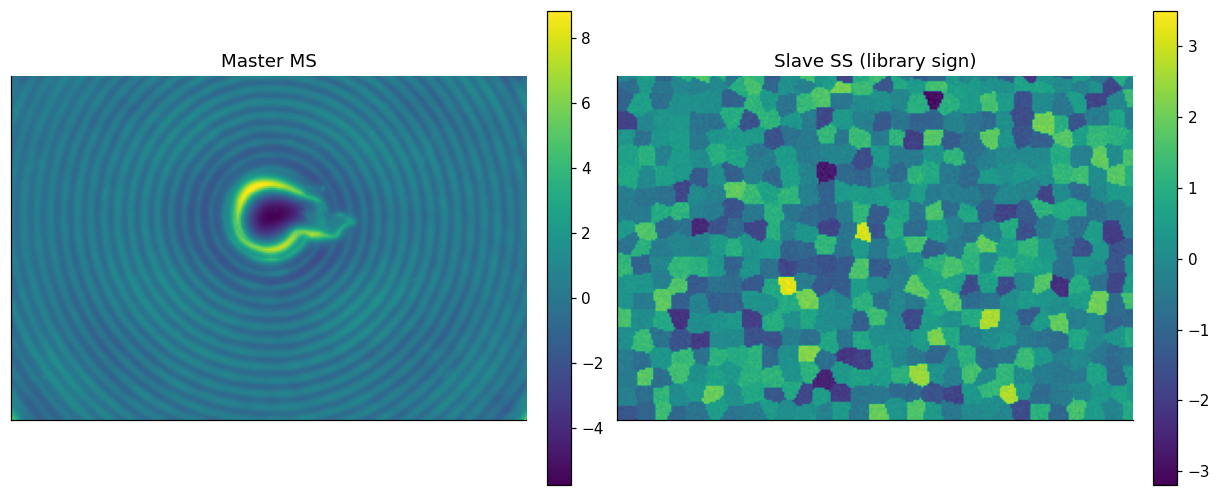

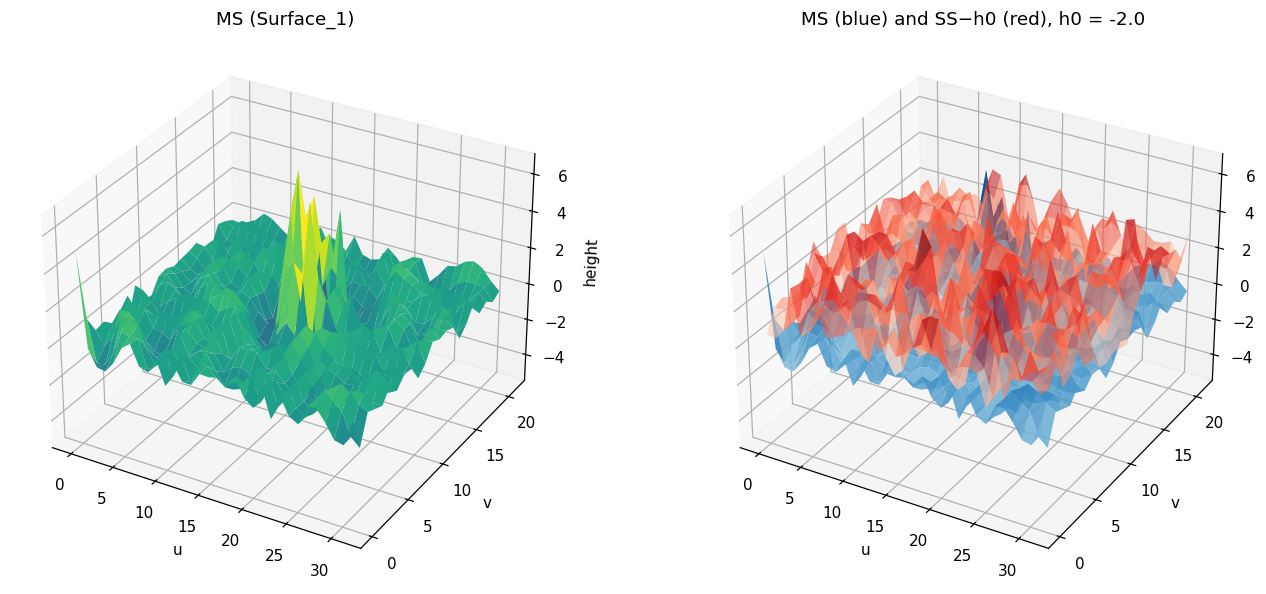

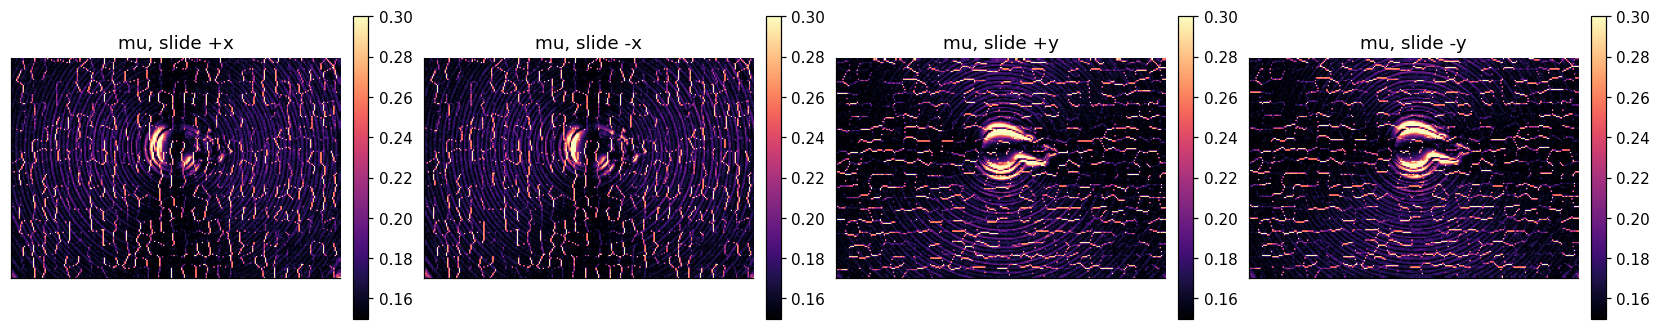

Mode: fixed-gap
h0: -2.0000
Contact texels: 2599 / 43776 = 5.94%
Total normal force: 5.2859e+02
Max traction: 5.5364e-01


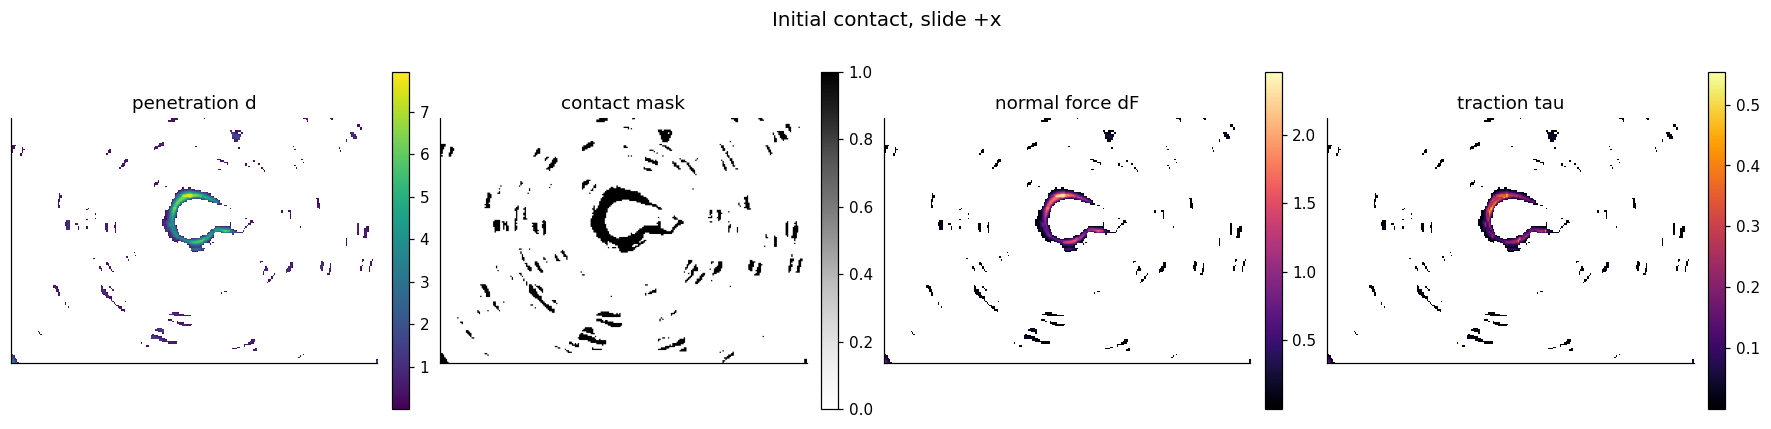

In [4]:
MS0, SS0 = select_pair(surfaces, MS_IDX, SS_IDX)
print(f"MS = Surface_{MS_IDX}, SS = -Surface_{SS_IDX}, sliding = {DIRECTION_NAMES[SLIDE_DIR]}")
print(f"MS range: {MS0.min():+.3f} .. {MS0.max():+.3f}")
print(f"SS range: {SS0.min():+.3f} .. {SS0.max():+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
imshow_field(axes[0], MS0, "Master MS")
imshow_field(axes[1], SS0, "Slave SS (library sign)")
plt.show()

plot_pair_3d(MS0, SS0)

fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
mu_maps = {d: combined_mu(MS0, SS0, demo_params, d) for d in (1, 2, 3, 4)}
mu_vmin, mu_vmax = robust_limits(mu_maps.values(), q=(0, 99))
for ax, d in zip(axes, (1, 2, 3, 4)):
    imshow_field(ax, mu_maps[d], f"mu, slide {DIRECTION_NAMES[d]}", cmap="magma", vmin=mu_vmin, vmax=mu_vmax)
plt.show()

contact0 = compute_contact(MS0, SS0, demo_params, SLIDE_DIR, LOAD_CONTROLLED)
print(f"Mode: {'load-controlled' if LOAD_CONTROLLED else 'fixed-gap'}")
print(f"h0: {contact0['h0']:.4f}")
print(f"Contact texels: {contact0['N']} / {MS0.size} = {100 * contact0['N'] / MS0.size:.2f}%")
print(f"Total normal force: {contact0['force']:.4e}")
print(f"Max traction: {contact0['tau'].max():.4e}")

plot_contact_dashboard(contact0, title=f"Initial contact, slide {DIRECTION_NAMES[SLIDE_DIR]}")


Optional **texture-aligned modulation** on top of the baseline `combined_mu` maps: use `tmd.surface.metrics.texture_modulated_pair_friction_maps` and `slide_azimuth_rad_from_direction` (see **Texture-modulated pair friction maps** in `docs/user-guide/tribology-metrics.md`).

## Wear simulation

`demo_params` uses a modest `wear_scale` and `wear_mode='topk'` so fixed-gap runs stay stable (the published MATLAB scale targets load-controlled forces).


In [5]:
final_state, log_rows, snapshots = run_simulation(
    MS0,
    SS0,
    demo_params,
    direction=SLIDE_DIR,
    n_steps=N_STEPS,
    load_controlled=LOAD_CONTROLLED,
    save_every=SAVE_EVERY,
)
log = pd.DataFrame(log_rows).set_index("step")
print(f"Ran {N_STEPS} steps, {len(snapshots)} snapshots")
log[["contact_percent", "normal_force", "wear_volume_MS", "wear_volume_SS", "cumulative_wear_sum_MS", "cumulative_wear_sum_SS", "energy_max_MS"]].head()


Ran 200 steps, 11 snapshots


,contact_percent,normal_force,wear_volume_MS,wear_volume_SS,cumulative_wear_sum_MS,cumulative_wear_sum_SS,energy_max_MS
step,,,,,,,
1,5.893640,519.387894,22.761569,6.230652,22.761569,6.230652,1.746814
2,5.909631,510.530643,26.701072,9.006428,49.462641,15.237081,2.262974
3,5.982730,502.386300,28.447584,11.951947,77.910225,27.189028,2.465068
4,6.026133,495.860358,30.995129,13.248785,108.905355,40.437813,2.126239
5,6.103801,488.948274,33.542674,14.580633,142.448029,55.018446,2.675412


## Diagnostics, evolution, cross-section

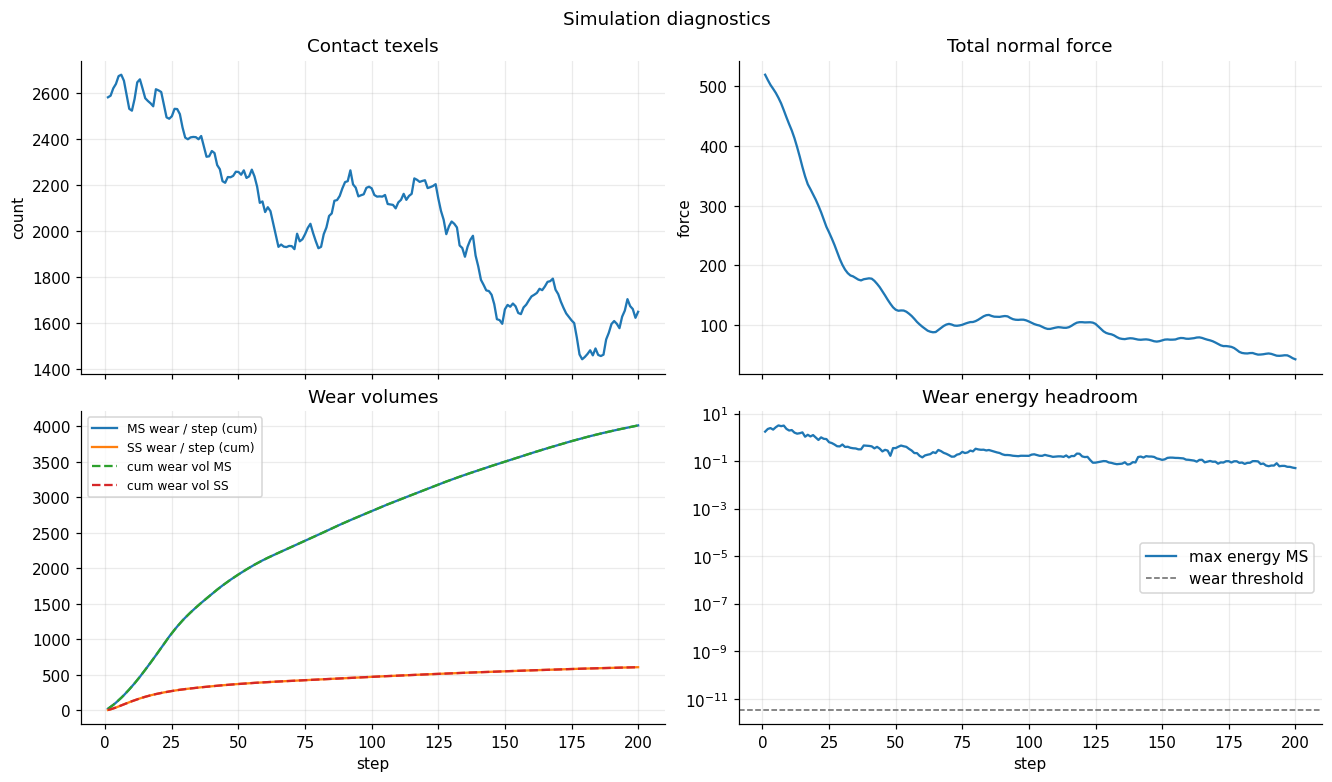

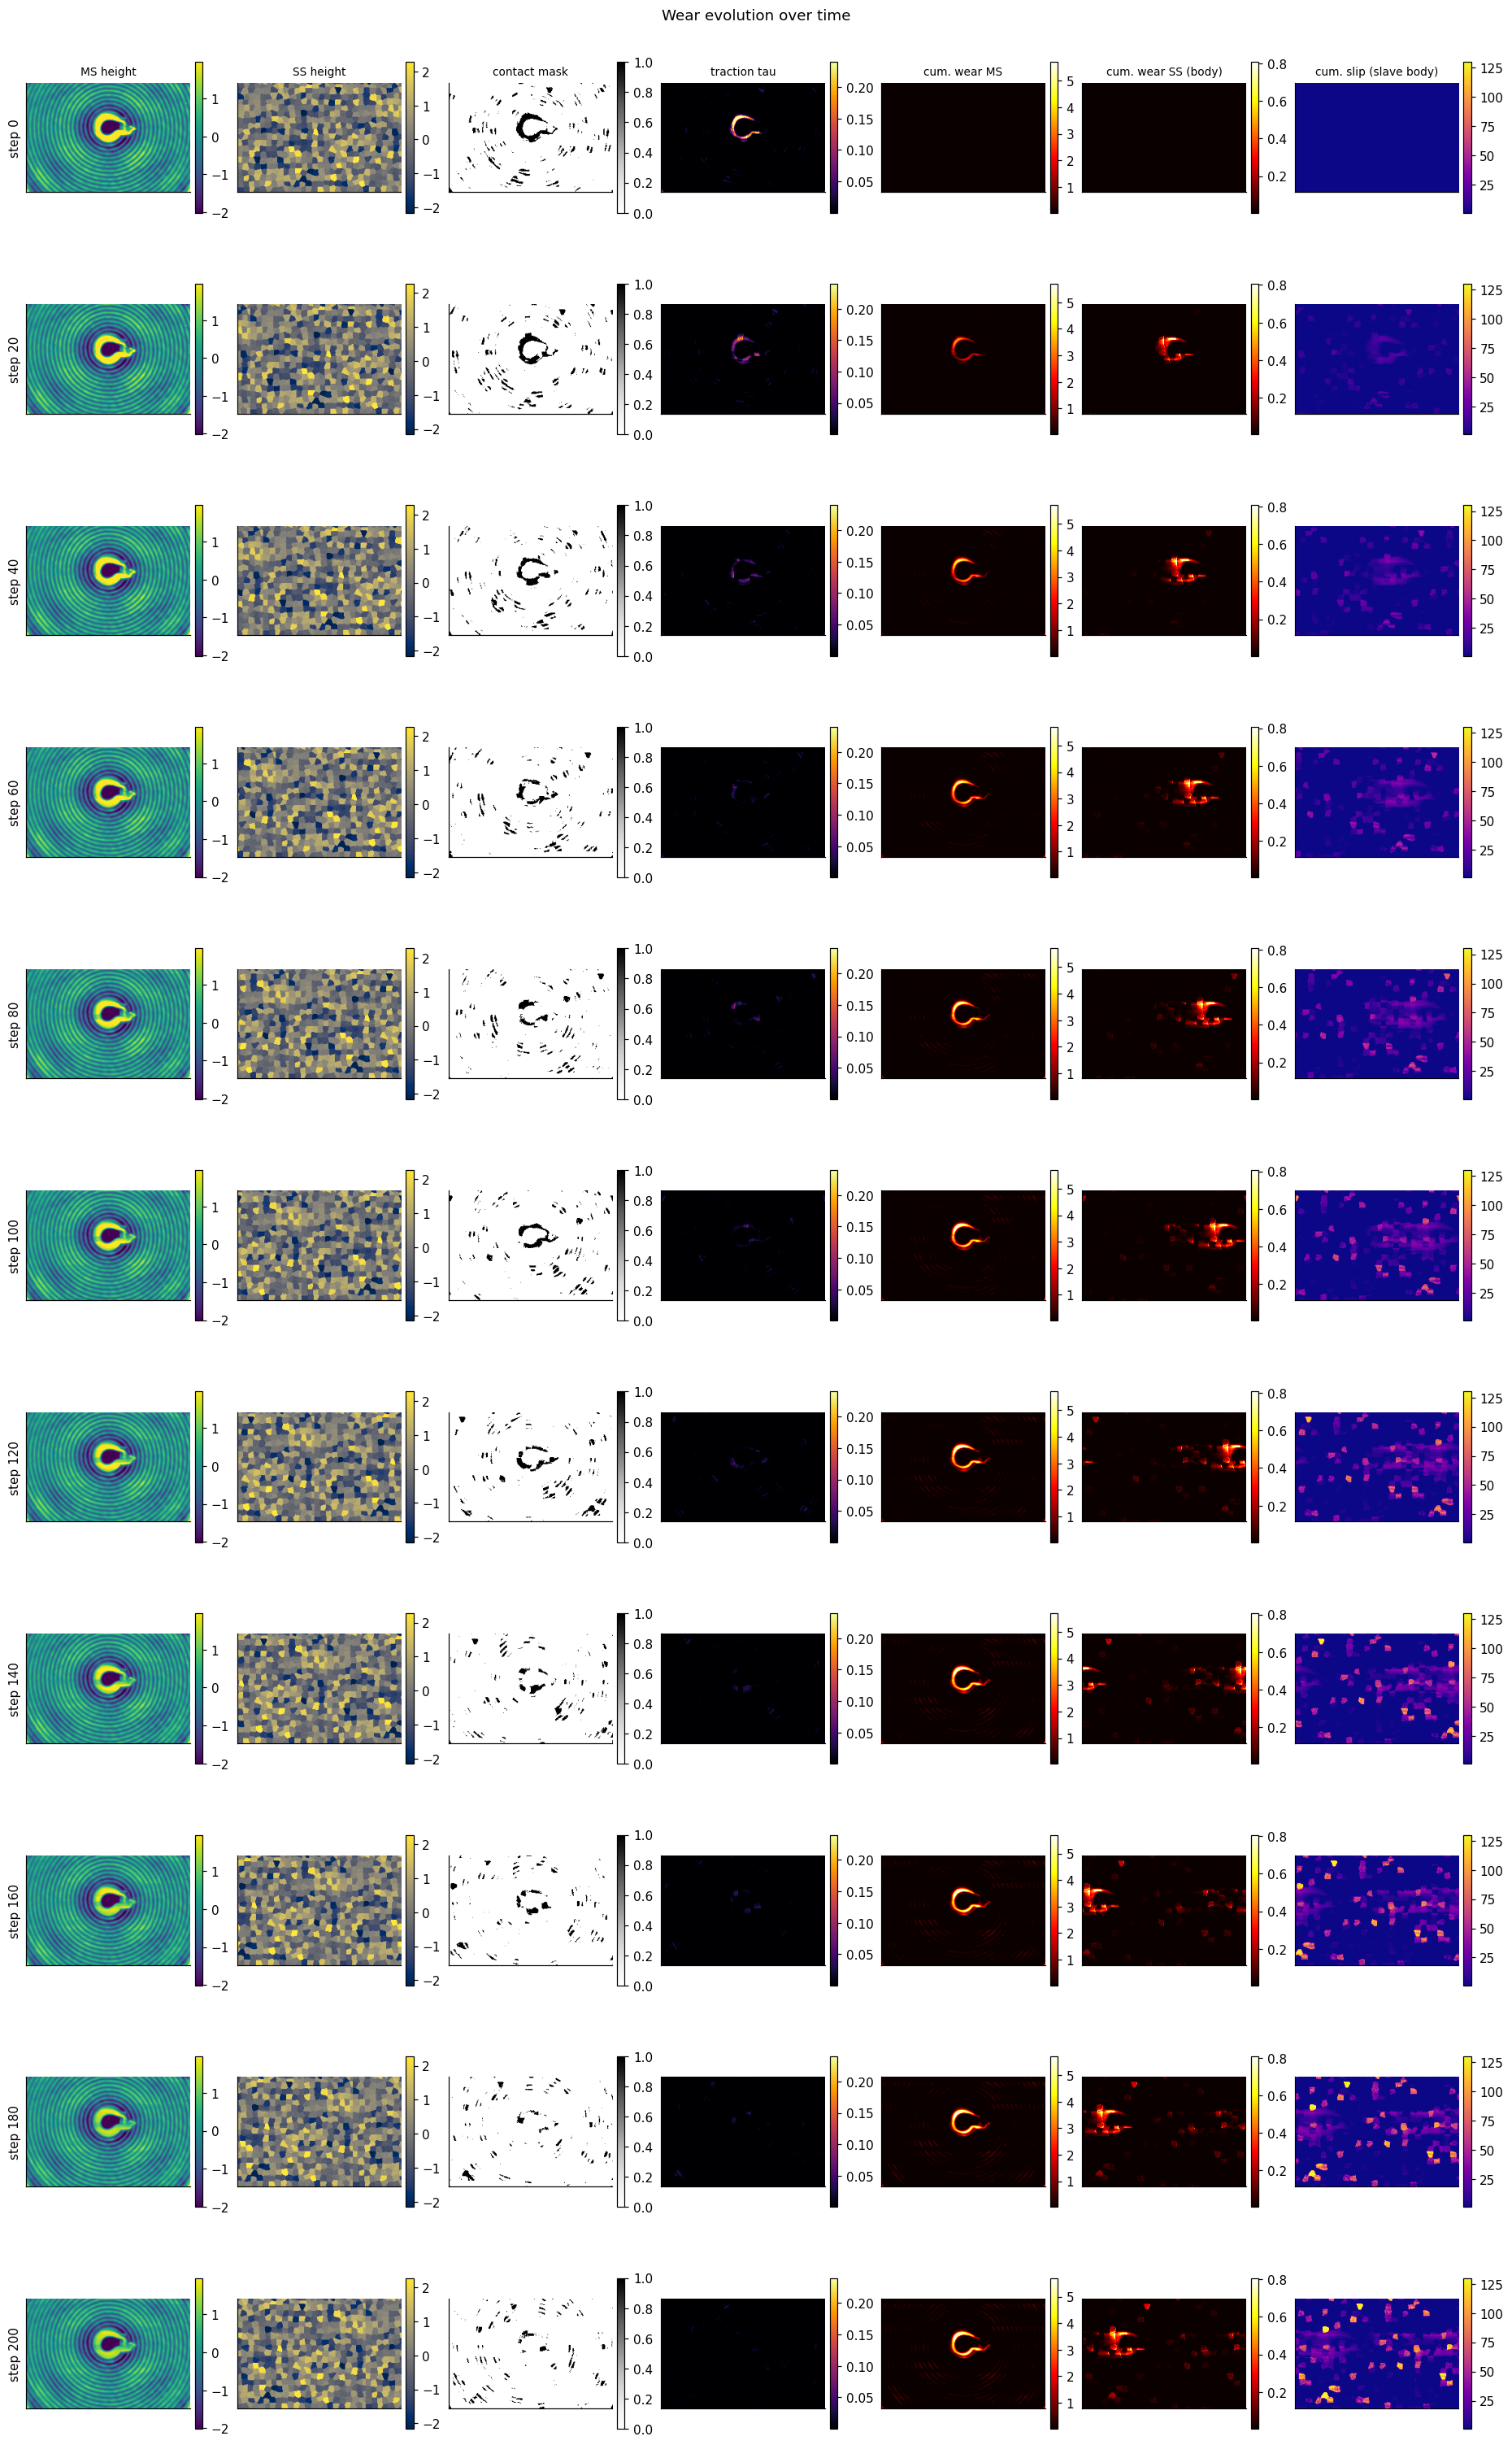

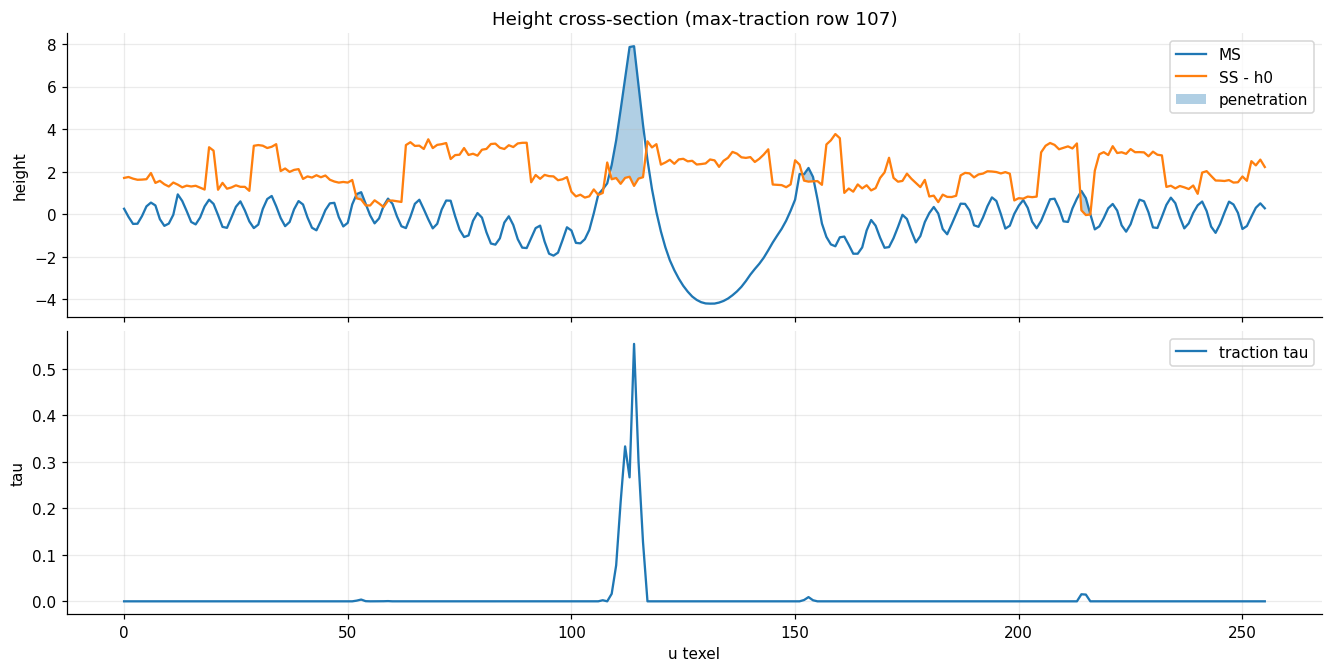

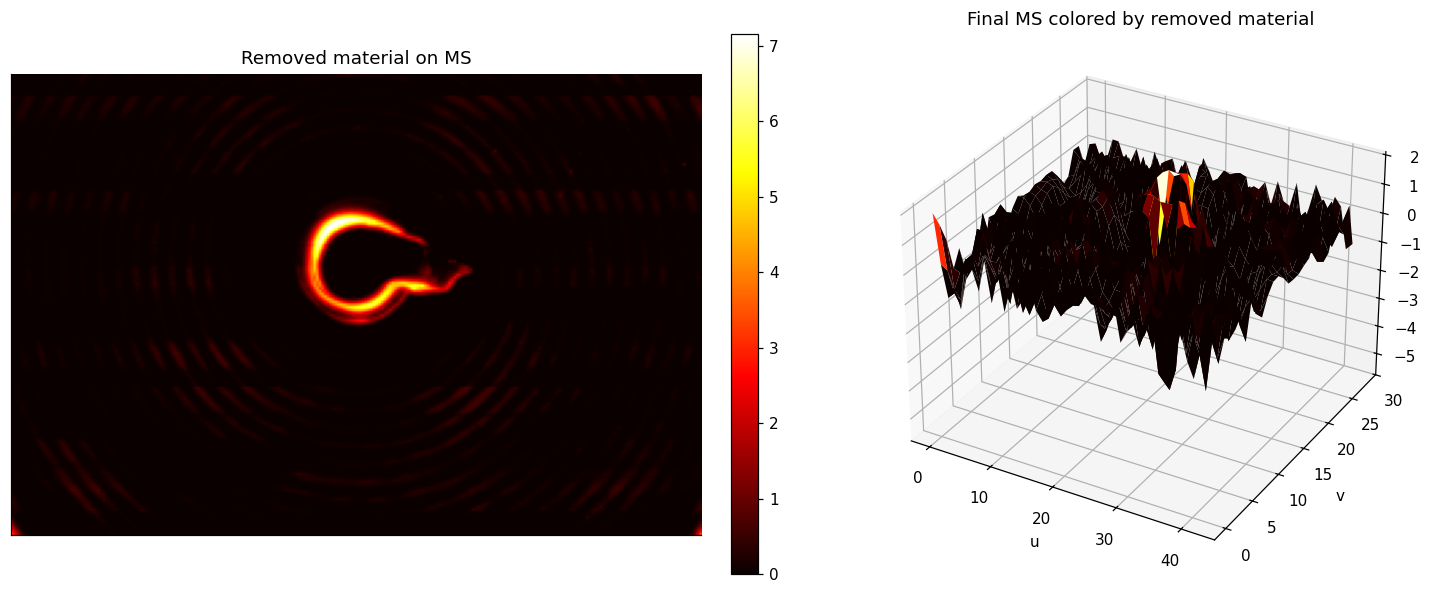

In [6]:
plot_diagnostics(log, demo_params)
plot_evolution_grid(snapshots)
plot_contact_cross_section(MS0, SS0, contact0)
plot_removed_material(MS0, final_state["MS"])


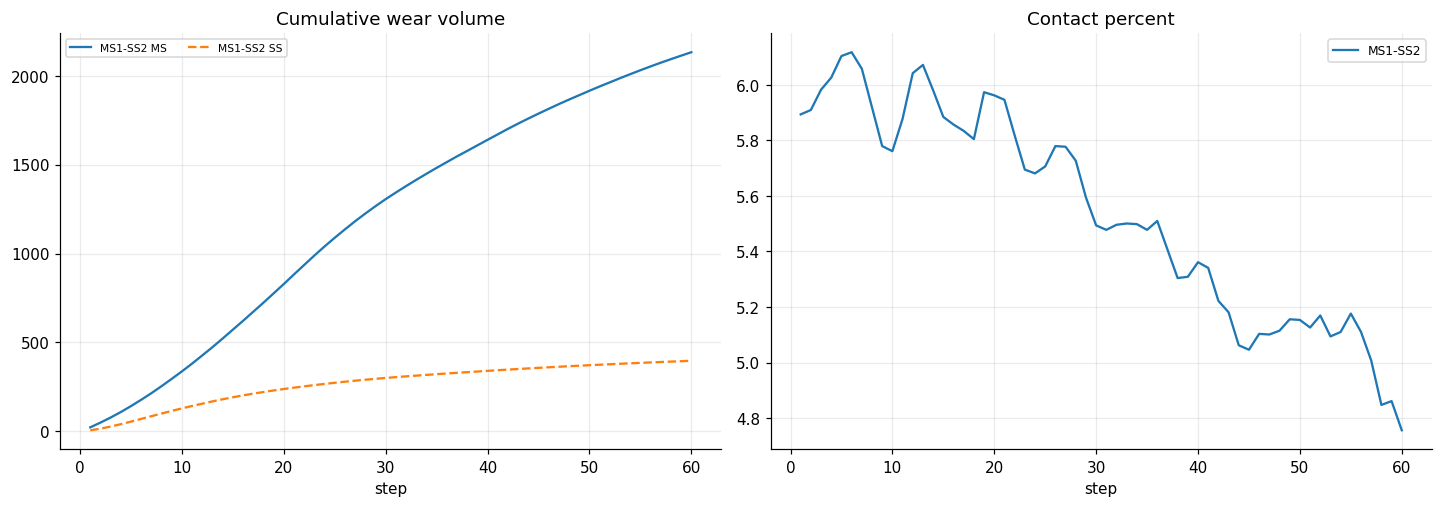

,final_contact_percent,cumulative_wear_MS,cumulative_wear_SS,mean_force
pair,,,,
MS1-SS2,4.75603,2132.0346,396.89327,257.02005


In [8]:
surface_keys = sorted(surfaces.keys())


def _valid_pairs(keys: List[int]) -> List[Tuple[int, int]]:
    preferred = [(1, 2), (3, 4), (5, 6), (1, 3), (2, 4), (5, 1)]
    valid = [pair for pair in preferred if pair[0] in keys and pair[1] in keys]
    if valid:
        return valid
    if len(keys) >= 2:
        return [(keys[0], keys[1])]
    raise ValueError("Need at least 2 surfaces for pair comparison")


pairs = _valid_pairs(surface_keys)
pair_rows, pair_history_rows = compare_surface_pairs(surfaces, pairs, demo_params, SLIDE_DIR, n_steps=60)
pair_table = pd.DataFrame(pair_rows).set_index("pair")
pair_histories = {label: pd.DataFrame(rows).set_index("step") for label, rows in pair_history_rows.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for label, hist in pair_histories.items():
    axes[0].plot(hist.index, hist["cumulative_wear_sum_MS"], label=f"{label} MS")
    axes[0].plot(hist.index, hist["cumulative_wear_sum_SS"], "--", label=f"{label} SS")
    axes[1].plot(hist.index, hist["contact_percent"], label=label)
axes[0].set_title("Cumulative wear volume")
axes[0].set_xlabel("step")
axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title("Contact percent")
axes[1].set_xlabel("step")
axes[1].legend(fontsize=8, ncol=2)
plt.show()
pair_table.round(5)


## GIF and exports

Saved E:\TrueMapData\notebooks\wear_results\wear_evolution.gif


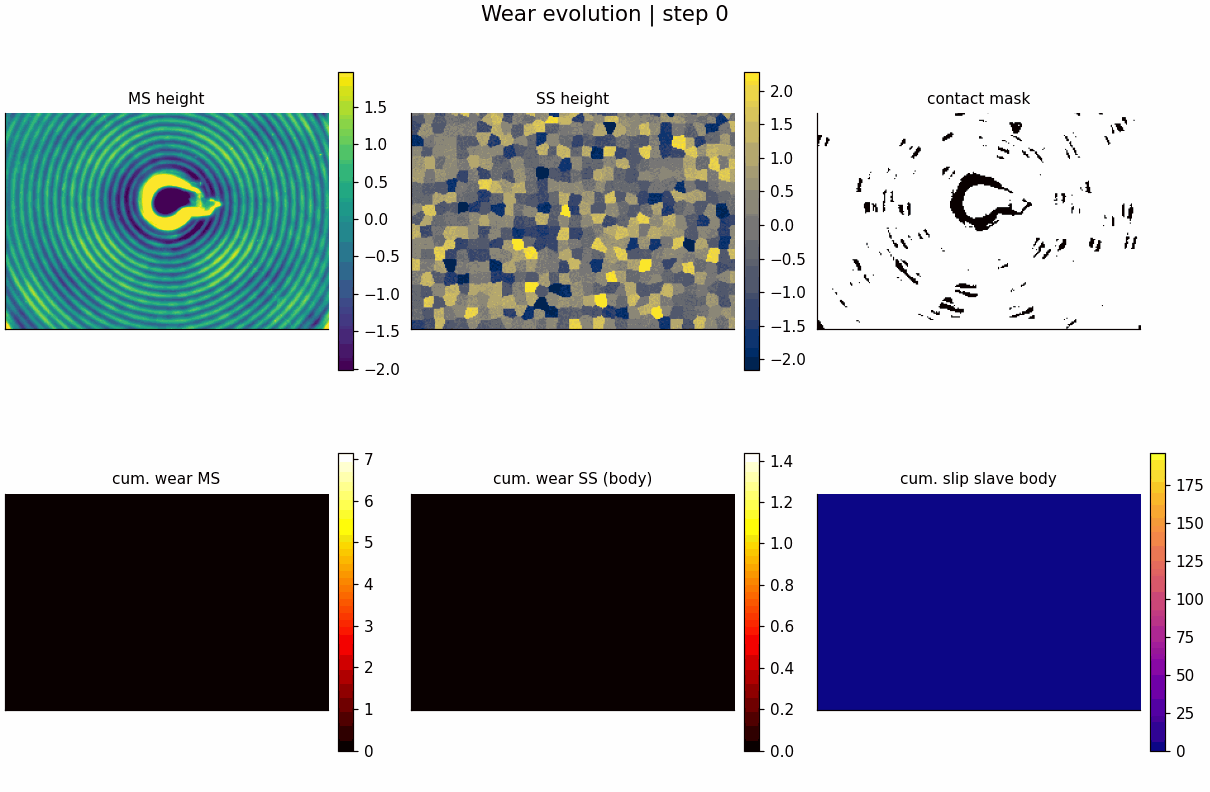

Saved E:\TrueMapData\notebooks\wear_results\final_state_surfaces.mat
Saved E:\TrueMapData\notebooks\wear_results\MS_final.obj
E:\TrueMapData\notebooks\wear_results\final_state.npz: 1657.1 KB
E:\TrueMapData\notebooks\wear_results\final_state_surfaces.mat: 1422.1 KB
E:\TrueMapData\notebooks\wear_results\MS_final.mtl: 0.1 KB
E:\TrueMapData\notebooks\wear_results\MS_final.obj: 1316.1 KB
E:\TrueMapData\notebooks\wear_results\normal_orientation_summary.csv: 0.3 KB
E:\TrueMapData\notebooks\wear_results\simulation_log.csv: 70.5 KB
E:\TrueMapData\notebooks\wear_results\snapshots.npz: 10268.8 KB
E:\TrueMapData\notebooks\wear_results\surface_metrics_before_after.csv: 0.5 KB
E:\TrueMapData\notebooks\wear_results\surface_pair_comparison.csv: 0.2 KB
E:\TrueMapData\notebooks\wear_results\truemap_metadata.json: 0.5 KB
E:\TrueMapData\notebooks\wear_results\wear_evolution.gif: 673.7 KB


['vs_reference', 'incremental']

In [9]:
WEAR_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
out_dir = WEAR_RESULTS_DIR

gif_path = make_animation(snapshots, str(out_dir / "wear_evolution.gif"))
print("Saved", gif_path)
try:
    display(Image(filename=gif_path))
except Exception as exc:
    print("GIF saved; embed skipped:", exc)

log.to_csv(out_dir / "simulation_log.csv")
metrics.to_csv(out_dir / "surface_metrics_before_after.csv")
orientation_table.to_csv(out_dir / "normal_orientation_summary.csv")
pair_table.to_csv(out_dir / "surface_pair_comparison.csv")
if truemap_metadata:
    meta_out = {k: (v if isinstance(v, (str, int, float, bool)) else str(v)) for k, v in truemap_metadata.items()}
    (out_dir / "truemap_metadata.json").write_text(json.dumps(meta_out, indent=2), encoding="utf-8")

np.savez_compressed(
    out_dir / "final_state.npz",
    MS_initial=MS0,
    SS_initial=SS0,
    MS_final=final_state["MS"],
    SS_final=final_state["SS"],
    removed_material=np.maximum(MS0 - final_state["MS"], 0.0),
    cumulative_wear_MS=final_state["cumulative_wear_MS"],
    cumulative_wear_SS=final_state["cumulative_wear_SS"],
    current_wear_increment_MS=final_state["last_wear_MS"],
    current_wear_increment_SS=final_state["last_wear_SS"],
    sliding_distance=final_state["sliding_distance"],
    sliding_distance_slave=final_state["sliding_distance_slave"],
)
np.savez_compressed(
    out_dir / "snapshots.npz",
    **{f"step_{s}_{name}": value for s, snap in snapshots.items() for name, value in snap.items()},
)

canonical_metadata = {
    **{k: (v if isinstance(v, (str, int, float, bool)) else str(v)) for k, v in truemap_metadata.items()},
    "slide_dir": int(SLIDE_DIR),
    "n_steps": int(N_STEPS),
    "save_every": int(SAVE_EVERY),
    "hardness_master": float(HARDNESS_MASTER),
    "hardness_slave": float(HARDNESS_SLAVE),
}
canonical_path = export_final_state_mat(
    out_dir / "final_state_surfaces.mat",
    ms_initial=MS0,
    ss_initial=SS0,
    final_state=final_state,
    surface_metrics_fn=surface_metrics_summary,
    extra_metadata=canonical_metadata,
)

model_obj_path = export_heightmap_to_model(
    np.asarray(final_state["MS"], dtype=np.float64),
    str(out_dir / "MS_final.obj"),
    "obj",
    triangulation_method="quadtree",
    z_scale=1.0,
    optimize=True,
)
print("Saved", canonical_path)
print("Saved", model_obj_path)

for path in sorted(out_dir.iterdir()):
    print(f"{path}: {path.stat().st_size / 1024:.1f} KB")

_seq = ms_snapshots_to_sequence(snapshots, name="wear-sim-ms", pitch_metadata=truemap_metadata)
_fr0 = _seq.get_frame(0)
if _fr0 is None:
    raise RuntimeError("No frames in sequence")
_md0 = _seq.get_frame_metadata(0) or {}
_dx, _dy = pixel_pitch_mm_from_metadata(simulation_metadata_to_pitch(_md0), _fr0.shape)
wear_vs_snapshots = _seq.sequential_wear_metrics(dx_mm=_dx, dy_mm=_dy, reference_index=0)
list(wear_vs_snapshots.keys())
